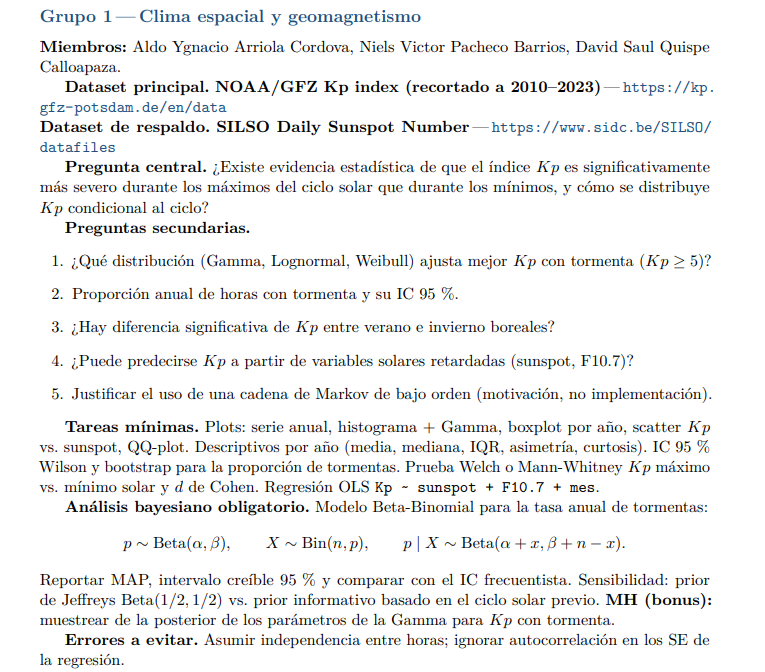

In [2]:
from datetime import datetime, timedelta
import time
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

import pandas as pd
import seaborn as sns

In [3]:
# Configuración estética global para el Notebook
plt.rcParams.update({
    "figure.facecolor": "white",    
    "axes.facecolor": "white",      
    "axes.edgecolor": "#333333",      
    "axes.linewidth": 0.8,
    "axes.grid": True,         
    "grid.color": "#e2e2e2",          
    "grid.linestyle": "--",      
    "grid.alpha": 0.7,
    "font.family": "sans-serif",     
    "font.size": 11,
    "axes.labelsize": 12,              
    "axes.titlesize": 14,              
    "xtick.labelsize": 10,             
    "ytick.labelsize": 10,            
    "figure.dpi": 100                  
})

## Loading the data

In [4]:
# geomagnetic and solar indices
# days : number of days since 1932-01-01
# days_m : mean day of days
# BSR : Bartels Solar Rotation Number, it changes every 27 days
# dB : specific day in the 1 - 27 range of the Bartels Solar Rotation Number
# Kp_i : pertubation index for the 3-hour interval i (00, 03, 06, 09, 12, 15, 18, 21) cuasi log scale 0 - 9
# ap_i : planetary index for the 3-hour interval i (00, 03, 06, 09, 12, 15, 18, 21), in nT, linear scale 0 - 400
# Ap : daily mean planetary index, in nT, linear scale 0 - 400....
# SN : Sunspot number
# D : if D = 2, we are working with definitve data, valided data

df_geom = pd.read_csv("data/geomagnetic-solarindices.txt", sep=r"\s+",header=None)
df_geom.columns = [
                    "year", "month", "day", "days", "days_m", 
                    "BSR", "dB", "Kp_00", "Kp_03", "Kp_06", 
                    "Kp_09", "Kp_12", "Kp_15", "Kp_18", "Kp_21", 
                    "ap_00","ap_03","ap_06","ap_09","ap_12","ap_15", 
                    "ap_18","ap_21","Ap", "SN", "F10.7obs", "F10.7adj", "D"
                ]
df_geom["date"] = pd.to_datetime(df_geom[["year", "month", "day"]])
# also, we might need the daily Kp (average) 
df_geom["Kp_daily"] = df_geom[["Kp_00", "Kp_03", 
                               "Kp_06", "Kp_09", 
                               "Kp_12", "Kp_15", 
                               "Kp_18", "Kp_21"]].mean(axis=1)
print("Kp and solar indices Dataset")
df_geom.head()

Kp and solar indices Dataset


,year,month,day,days,days_m,BSR,dB,Kp_00,Kp_03,Kp_06,...,ap_15,ap_18,ap_21,Ap,SN,F10.7obs,F10.7adj,D,date,Kp_daily
0,2010,1,1,28490,28490.5,2407,15,0.000,0.000,0.000,...,0,0,4,0,18,75.2,72.7,2,2010-01-01,0.125000
1,2010,1,2,28491,28491.5,2407,16,0.000,0.000,0.333,...,2,2,2,1,21,78.0,75.4,2,2010-01-02,0.208125
2,2010,1,3,28492,28492.5,2407,17,0.333,1.333,0.667,...,3,0,2,4,16,76.4,73.8,2,2010-01-03,0.875000
3,2010,1,4,28493,28493.5,2407,18,0.333,0.000,1.333,...,0,2,0,2,15,73.0,70.6,2,2010-01-04,0.416500
4,2010,1,5,28494,28494.5,2407,19,0.000,0.000,0.000,...,4,2,0,1,10,76.8,74.3,2,2010-01-05,0.250000


In [5]:
# sunspot number dataset
df_sn = pd.read_csv("data/SN_d_tot_V2.0.txt", sep=r"\s+", header=None)
df_sn.columns = ["year", "month", "day", "date_year_fraction", "daily_total_sn", "daily_std_sn", "obs_number"]#, "indicator"]
# only years from 2010 to 2023
df_sn = df_sn[(2010<=df_sn["year"]) & (df_sn["year"]<=2023)  ]
df_sn["date"] = pd.to_datetime(df_sn[["year", "month", "day"]])
print("Sunspot Number Dataset")
df_sn.head()

Sunspot Number Dataset


,year,month,day,date_year_fraction,daily_total_sn,daily_std_sn,obs_number,date
70127,2010,1,1,2010.001,18,1.3,15,2010-01-01
70128,2010,1,2,2010.004,21,1.2,16,2010-01-02
70129,2010,1,3,2010.007,16,2.0,17,2010-01-03
70130,2010,1,4,2010.010,15,0.8,14,2010-01-04
70131,2010,1,5,2010.012,10,2.3,17,2010-01-05


In [6]:
kp_cols = ["Kp_00", "Kp_03", "Kp_06", "Kp_09", "Kp_12", "Kp_15", "Kp_18", "Kp_21"]
df_kp = pd.melt(df_geom, id_vars=["year", "month", "day"], value_vars=kp_cols, var_name="hour_str", value_name="Kp")
df_kp["hour"] = df_kp["hour_str"].str.replace("Kp_", "")
df_kp["datetime"] = pd.to_datetime(
    df_kp["year"].astype(str) + "-" + df_kp["month"].astype(str) + "-" + df_kp["day"].astype(str)
    + " " + df_kp["hour"]+ ":00:00" 
    )
df_kp = df_kp[["datetime", "Kp"]].sort_values("datetime").reset_index(drop=True)
df_kp.head()

,datetime,Kp
0,2010-01-01 00:00:00,0.0
1,2010-01-01 03:00:00,0.0
2,2010-01-01 06:00:00,0.0
3,2010-01-01 09:00:00,0.0
4,2010-01-01 12:00:00,0.0


## Descriptive steps

Text(0.5, 0, 'Time')

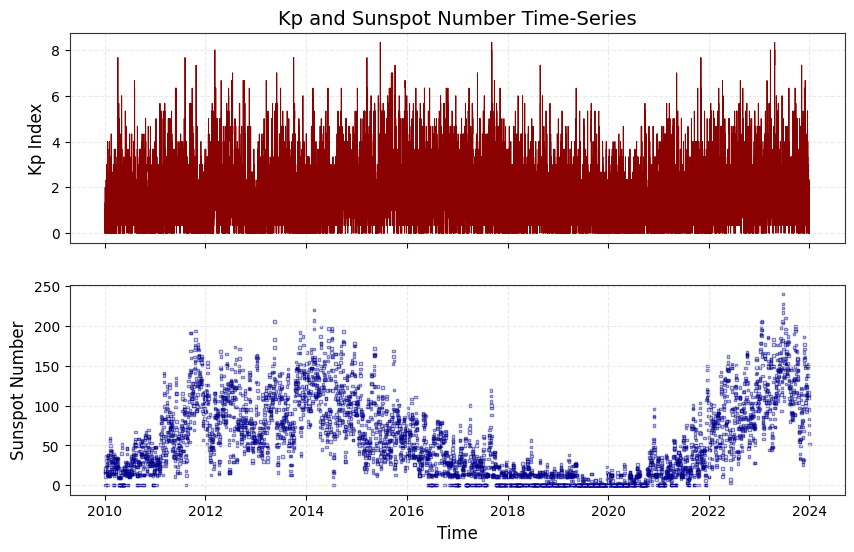

In [17]:
fig, axs = plt.subplots(nrows=2, figsize=(10,6), sharex=True)
ax = axs[0]
ax.step(df_kp["datetime"], df_kp["Kp"], color="darkred", lw=0.7)
#ax.scatter(df_kp["datetime"], df_kp["Kp"], marker="o", facecolor="none", edgecolor="darkred", s=3, alpha=0.5)
ax.set_ylabel("Kp Index")
ax.set_title("Kp and Sunspot Number Time-Series")
ax = axs[1]
ax.scatter(df_geom["date"], df_geom["SN"], marker="s", facecolor="none", edgecolor="darkblue", s=3, alpha=0.5)
ax.set_ylabel("Sunspot Number")

plt.xlabel("Time")

print("Se logra observar, visuzalmente, una correlacion entre Kp y SN.")

In [11]:
df_geom.head()

,year,month,day,days,days_m,BSR,dB,Kp_00,Kp_03,Kp_06,...,ap_15,ap_18,ap_21,Ap,SN,F10.7obs,F10.7adj,D,date,Kp_daily
0,2010,1,1,28490,28490.5,2407,15,0.000,0.000,0.000,...,0,0,4,0,18,75.2,72.7,2,2010-01-01,0.125000
1,2010,1,2,28491,28491.5,2407,16,0.000,0.000,0.333,...,2,2,2,1,21,78.0,75.4,2,2010-01-02,0.208125
2,2010,1,3,28492,28492.5,2407,17,0.333,1.333,0.667,...,3,0,2,4,16,76.4,73.8,2,2010-01-03,0.875000
3,2010,1,4,28493,28493.5,2407,18,0.333,0.000,1.333,...,0,2,0,2,15,73.0,70.6,2,2010-01-04,0.416500
4,2010,1,5,28494,28494.5,2407,19,0.000,0.000,0.000,...,4,2,0,1,10,76.8,74.3,2,2010-01-05,0.250000


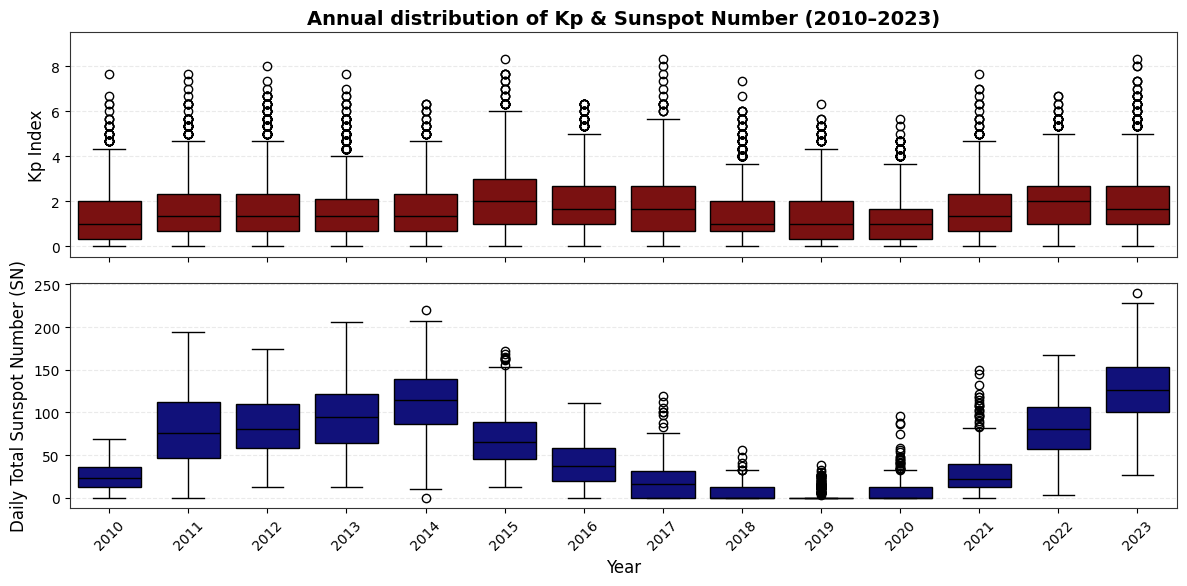

In [17]:
fig, axs = plt.subplots(nrows=2, figsize=(12, 6), sharex=True)

ax = axs[0]

# Boxplot per year
df_kp['year'] = df_kp['datetime'].dt.year

sns.boxplot(data=df_kp, x="year", y="Kp", color = 'darkred', linecolor = 'black', ax=ax)

ax.set_title("Annual distribution of Kp & Sunspot Number (2010–2023)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Kp Index", fontsize=12)
ax.set_ylim(-0.5, 9.5)
# plt.xticks(rotation=45)

ax = axs[1]
sns.boxplot(data=df_sn, x="year", y="daily_total_sn", color = 'darkblue', linecolor = 'black', ax=ax)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Daily Total Sunspot Number (SN)", fontsize=12)
#plt.ylim(-0.5, 9.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
# Distribición Conjunta: se requiere Kp y SN alineados en X
# dado que Kp es una medida cuasi logaritmica y equivalente lieal es la variable Ap (promedio diario)


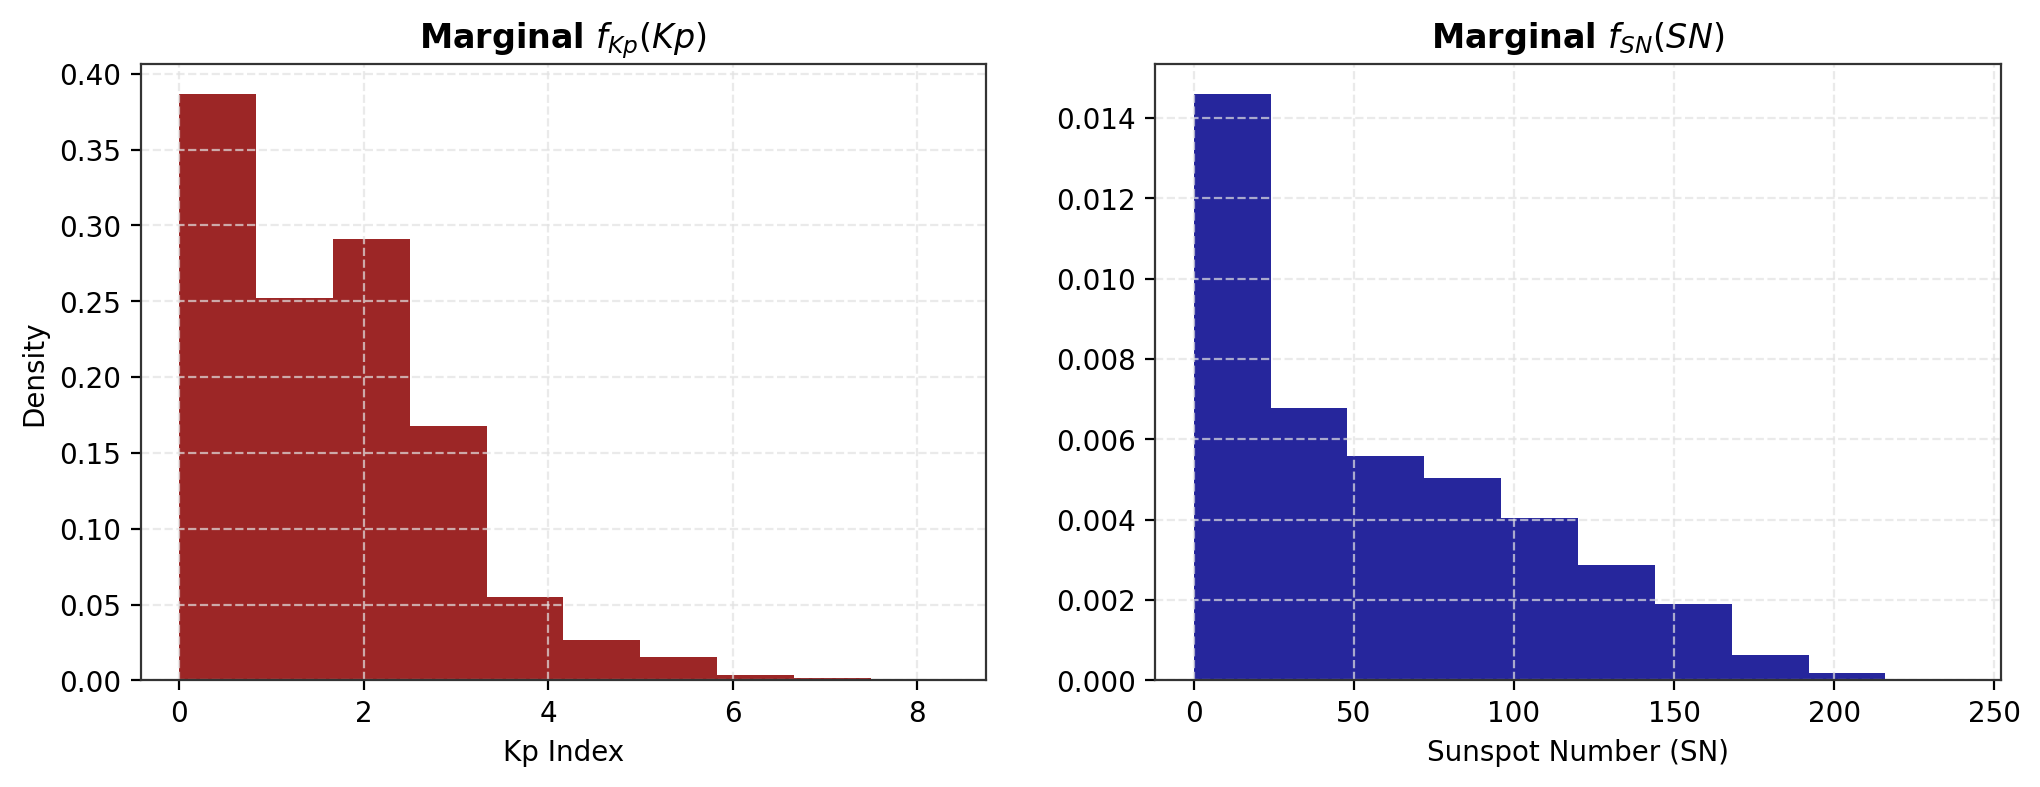

<Figure size 640x480 with 0 Axes>

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), dpi = 200)

axs[0].hist(df_kp["Kp"], bins = 10, color = 'darkred', density = True, edgecolor = 'none', alpha = 0.85)
axs[0].set_title(r"Marginal $f_{Kp}(Kp)$", fontsize=12, fontweight="bold")
axs[0].set_xlabel("Kp Index", fontsize=10)
axs[0].set_ylabel("Density", fontsize=10)

axs[1].hist(df_sn["daily_total_sn"], bins = 10, color = 'darkblue', density = True, edgecolor = 'none', alpha = 0.85)
axs[1].set_title(r"Marginal $f_{SN}(SN)$", fontsize=12, fontweight="bold")
axs[1].set_xlabel(r"Sunspot Number (SN)", fontsize=10)
#axs[1].set_ylabel("Density", fontsize=10)

plt.show()

# fig, ax = plt.subplots()


plt.tight_layout()

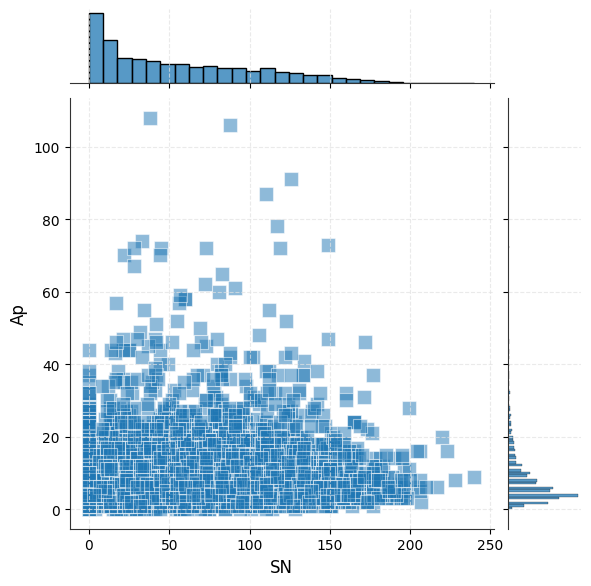

In [29]:
# sns.jointplot(data=df_geom, x="SN", y="Ap", kind="hist")
sns.jointplot(data=df_geom, x="SN", y="Ap", marker="s", s=100,alpha=0.5)

### Gamma, Lognormal and weibull for Kp >5 (storm)

Fit Params:
 - Gamma    : shape = 0.4413 / scale = 1.3133
 - Lognormal: sigma = 2.3881 / scale = 0.1335
 - Weibull  : shape = 0.5682 / scale = 0.4044

AIC for each model:
 - Gamma    : 192.4103
 - Lognormal: 393.7636
 - Weibull: 260.2075


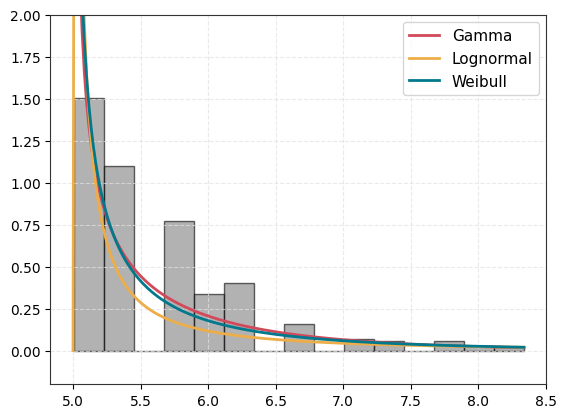

In [48]:
# Gamma, Lognormal and weibull for Kp >5 (storm)

kp_storm = df_kp["Kp"][df_kp["Kp"]>=5].dropna().values + 0.005 # +0.05 to avoid 5.0 values due to 'gamma' requires that 5 < (x - loc)/scale  < inf f 

FLOC = 5
threshold = 5

# model fit, ignoramos el retorno de loc
shape_gamma, loc_gamma, scale_gamma = stats.gamma.fit(kp_storm, floc=FLOC)
sigma_logn, loc_logn, scale_logn   = stats.lognorm.fit(kp_storm, floc=FLOC)
c_weibull, loc_weibull, scale_weibull = stats.weibull_min.fit(kp_storm, floc=FLOC)


print("Fit Params:")
print(f" - Gamma    : shape = {shape_gamma:.4f} / scale = {scale_gamma:.4f}")
print(f" - Lognormal: sigma = {sigma_logn:.4f} / scale = {scale_logn:.4f}")
print(f" - Weibull  : shape = {c_weibull:.4f} / scale = {scale_weibull:.4f}")

# log likelihood, hacemos 
ll_gamma   = stats.gamma.logpdf(kp_storm, a=shape_gamma, loc=FLOC, scale=scale_gamma).sum()
ll_lognorm = stats.lognorm.logpdf(kp_storm, s=sigma_logn, loc=FLOC, scale=scale_logn).sum()
ll_weibull = stats.weibull_min.logpdf(kp_storm, c=c_weibull, loc=FLOC, scale=scale_weibull).sum() 

# validamos con AIC: nro de params=2 para cada modelo
k=2
n= len(kp_storm)

aic_gamma = -2 * ll_gamma + 2*k
aic_weibull = -2 * ll_weibull + 2*k
aic_lognorm = -2 * ll_lognorm + 2*k

print("\nAIC for each model:")
print(f" - Gamma    : {aic_gamma:.4f}")
print(f" - Lognormal: {aic_lognorm:.4f}")
print(f" - Weibull: {aic_weibull:.4f}")

# el modelo Lognormal es el que mejor se ajusta a los datos

x_fit = np.linspace(5, kp_storm.max(), 200)

fig = plt.figure()
plt.hist(kp_storm, bins=15, edgecolor="black", facecolor="gray", density=True, alpha=0.6)

plt.plot(x_fit, stats.gamma.pdf(x_fit, a=shape_gamma, loc=FLOC, scale=scale_gamma),
        color="#D1495B", lw=2, label="Gamma")
plt.plot(x_fit, stats.lognorm.pdf(x_fit, s=sigma_logn, loc=FLOC,scale=scale_logn),
        color="#EDAE49", lw=2, label="Lognormal")
plt.plot(x_fit, stats.weibull_min.pdf(x_fit, c=c_weibull, loc=FLOC,scale=scale_weibull),
        color="#00798C", lw=2, label="Weibull")

plt.ylim(-0.2,2)
plt.legend()

plt.show()